## Cold Loading Alternating Files vs Cold Loading of Same File Experiment

Some properties:
- chrX.fna and chr8.fna files used
- No. of repetitions: 5
- File Sizes:
    - chrX.fna: 151MB
    - chr8.fna: 140MB
- Device:
    - Macbook Air 2025
    - Processor: M4
    - RAM: 16GB
    - OS: Tahoe 26.3
- Loading Program:
    - C++20, O3, march=native
    - Algorithm: read line per line. Naive and inefficient
    - Implementation: t21.impl_0

In [26]:
# alt_file_chrX, same_file_chr8 and alt_file_chr8 dataframes
# all info is in ./results.csv
import pandas as pd
results_df = pd.read_csv("results.csv", index_col=0)
results_l0_df = results_df[results_df["opt_level"] == 0]
same_file_chrX = results_l0_df[(results_l0_df["file"] == "chrX.fna") & (results_l0_df["same_files"] == True)]
alt_file_chrX = results_l0_df[(results_l0_df["file"] == "chrX.fna") & (results_l0_df["same_files"] == False)]
same_file_chr8 = results_l0_df[(results_l0_df["file"] == "chr8.fna") & (results_l0_df["same_files"] == True)]
alt_file_chr8 = results_l0_df[(results_l0_df["file"] == "chr8.fna") & (results_l0_df["same_files"] == False)]

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_25464/1298420073.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([same_file_chrX["time"] * 1000, alt_file_chrX["time"] * 1000], labels=["Same File", "Alt File"])


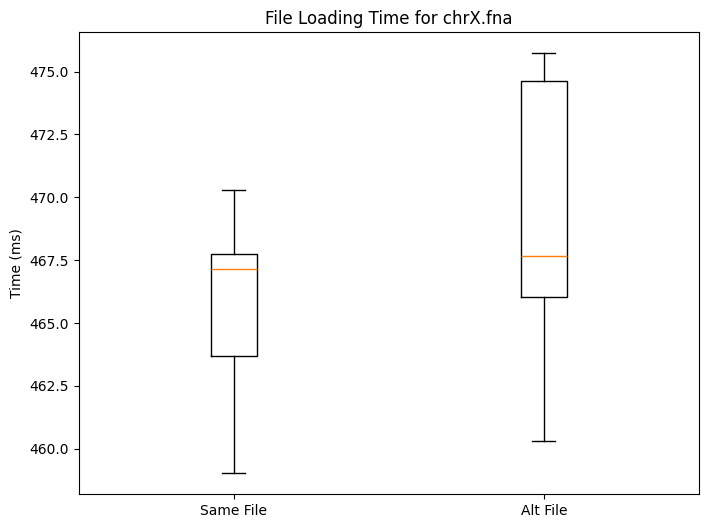

In [27]:
# Make a boxplot of same_file_chrX["time"]. It's in seconds with 6 decimal places, so we can round to milliseconds for better visualization.
# and also for alt_file_chrX. Both in the same plot for comparison.
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.boxplot([same_file_chrX["time"] * 1000, alt_file_chrX["time"] * 1000], labels=["Same File", "Alt File"])
plt.ylabel("Time (ms)")
plt.title("File Loading Time for chrX.fna")
plt.show()

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_25464/2324018103.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([same_file_chr8["time"] * 1000, alt_file_chr8["time"] * 1000], labels=["Same File", "Alt File"])


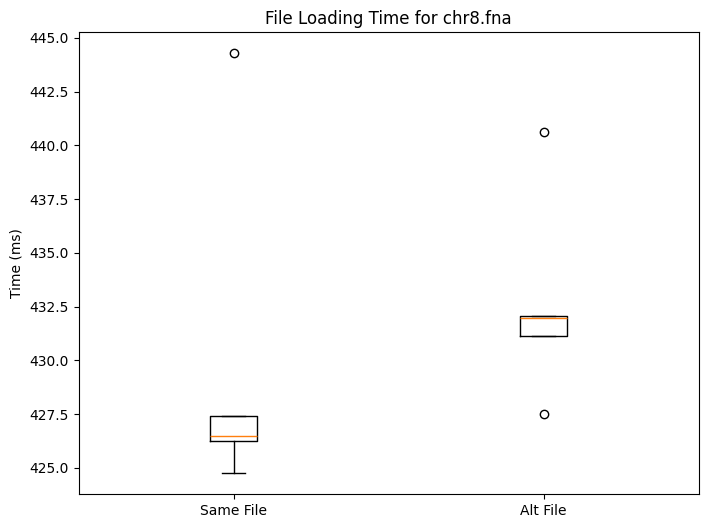

In [28]:
plt.figure(figsize=(8, 6))
plt.boxplot([same_file_chr8["time"] * 1000, alt_file_chr8["time"] * 1000], labels=["Same File", "Alt File"])
plt.ylabel("Time (ms)")
plt.title("File Loading Time for chr8.fna")
plt.show()

In [29]:
# in a boxplot, the line in the middle of the box is the: median is higher when alternating and the whiskers are also higher to their counterparts.
# this suggests times usually perform worse when alternating files.
# Give some descritive summar stadistics in a table form:

summary_chrX_df = pd.DataFrame({
    "Same File": [same_file_chrX["time"].mean() * 1000, same_file_chrX["time"].std() * 1000],
    "Alt File": [alt_file_chrX["time"].mean() * 1000, alt_file_chrX["time"].std() * 1000]
}, index=["Mean (ms)", "Std Dev (ms)"])

summary_chr8_df = pd.DataFrame({
    "Same File": [same_file_chr8["time"].mean() * 1000, same_file_chr8["time"].std() * 1000],
    "Alt File": [alt_file_chr8["time"].mean() * 1000, alt_file_chr8["time"].std() * 1000]
}, index=["Mean (ms)", "Std Dev (ms)"])

print("Summary Statistics for chrX.fna:")
print(summary_chrX_df)
print("\nSummary Statistics for chr8.fna:")
print(summary_chr8_df)

Summary Statistics for chrX.fna:
               Same File   Alt File
Mean (ms)     465.572000  468.86660
Std Dev (ms)    4.356376    6.37954

Summary Statistics for chr8.fna:
               Same File   Alt File
Mean (ms)     429.827600  432.65340
Std Dev (ms)    8.134943    4.83754


### Discussion

Alternating files appear to affect the performance of cold loading files. The mean is not very affected, as it increased only 3ms in each case. However, the distribution is more skewed to the right (longer times) when alternating files.

In [30]:
results_l1_df = results_df[results_df["opt_level"] == 1]
l1_same_file_chrX = results_l1_df[(results_l1_df["file"] == "chrX.fna") & (results_l1_df["same_files"] == True)]
l1_same_file_chr8 = results_l1_df[(results_l1_df["file"] == "chr8.fna") & (results_l1_df["same_files"] == True)]


## Naive Read Line (until \n) vs 80-character knowledge explotation

Some properties:
- chrX.fna and chr8.fna files used
- No. of repetitions: 5
- File Sizes:
    - chrX.fna: 151MB
    - chr8.fna: 140MB
- Device:
    - Macbook Air 2025
    - Processor: M4
    - RAM: 16GB
    - OS: Tahoe 26.3
- Loading Program:
    - C++20, O3, march=native
    - Algorithm: read 80+1 characters directly from the file
    - Implementation: t21.impl_1

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_25464/4233345637.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([same_file_chrX["time"] * 1000, l1_same_file_chrX["time"] * 1000], labels=["Opt Level 0", "Opt Level 1"])


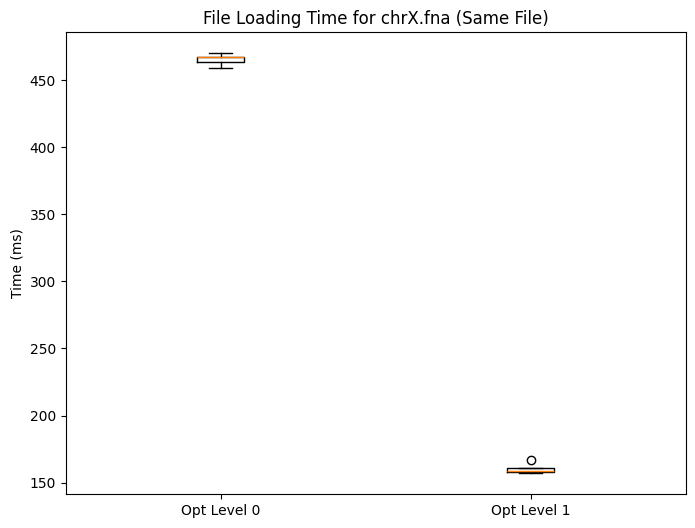

In [31]:
# Compare chrX l0 (normal dataframe name) vs l1 (l1_same_file_chrX) to see if there is a difference in loading times when using optimization level 1. We can do the same for chr8.
# Using boxplots again for comparison.
plt.figure(figsize=(8, 6))
plt.boxplot([same_file_chrX["time"] * 1000, l1_same_file_chrX["time"] * 1000], labels=["Opt Level 0", "Opt Level 1"])
plt.ylabel("Time (ms)")
plt.title("File Loading Time for chrX.fna (Same File)")
plt.show()

/var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_25464/2492279575.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([same_file_chr8["time"] * 1000, l1_same_file_chr8["time"] * 1000], labels=["Opt Level 0", "Opt Level 1"])


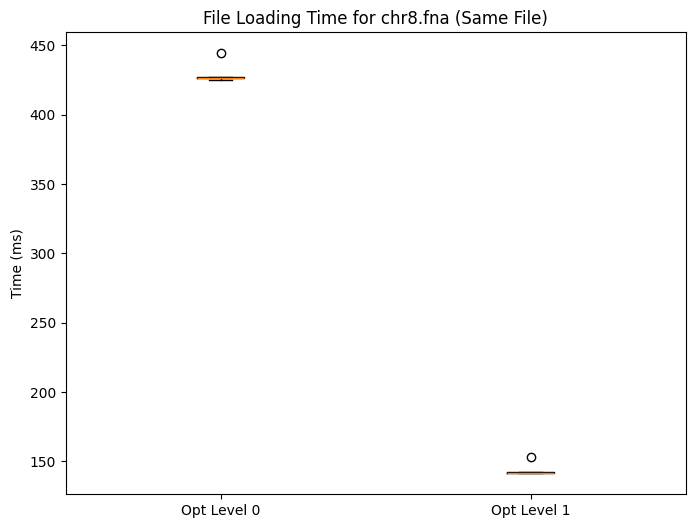

In [32]:
# Compare chr8
plt.figure(figsize=(8, 6))
plt.boxplot([same_file_chr8["time"] * 1000, l1_same_file_chr8["time"] * 1000], labels=["Opt Level 0", "Opt Level 1"])
plt.ylabel("Time (ms)")
plt.title("File Loading Time for chr8.fna (Same File)")
plt.show()

In [39]:
# Know table comparisons of mean and std dev for same_file_chrX and l1_same_file_chrX, and same_file_chr8 and l1_same_file_chr8.
summary_chrX_opt_df = pd.DataFrame({
    "Opt Level 0": [same_file_chrX["time"].mean() * 1000, same_file_chrX["time"].std() * 1000],
    "Opt Level 1": [l1_same_file_chrX["time"].mean() * 1000, l1_same_file_chrX["time"].std() * 1000]
}, index=["Mean (ms)", "Std Dev (ms)"]) 

summary_chr8_opt_df = pd.DataFrame({
    "Opt Level 0": [same_file_chr8["time"].mean() * 1000, same_file_chr8["time"].std() * 1000],
    "Opt Level 1": [l1_same_file_chr8["time"].mean() * 1000, l1_same_file_chr8["time"].std() * 1000]
}, index=["Mean (ms)", "Std Dev (ms)"])




print("Summary Statistics for chrX.fna (Opt Level Comparison):")
print(summary_chrX_opt_df)
mean_speedup_chrX = summary_chrX_opt_df.loc["Mean (ms)", "Opt Level 0"] / summary_chrX_opt_df.loc["Mean (ms)", "Opt Level 1"]
print(f"Mean Speedup for chrX.fna: {mean_speedup_chrX:.2f}x")

print("\nSummary Statistics for chr8.fna (Opt Level Comparison):")
print(summary_chr8_opt_df)
mean_speedup_chr8 = summary_chr8_opt_df.loc["Mean (ms)", "Opt Level 0"] / summary_chr8_opt_df.loc["Mean (ms)", "Opt Level 1"]
print(f"Mean Speedup for chr8.fna: {mean_speedup_chr8:.2f}x")


#

Summary Statistics for chrX.fna (Opt Level Comparison):
              Opt Level 0  Opt Level 1
Mean (ms)      465.572000   160.213400
Std Dev (ms)     4.356376     4.137075
Mean Speedup for chrX.fna: 2.91x

Summary Statistics for chr8.fna (Opt Level Comparison):
              Opt Level 0  Opt Level 1
Mean (ms)      429.827600    143.98100
Std Dev (ms)     8.134943      5.00039
Mean Speedup for chr8.fna: 2.99x


## Discussion
There is a great improvement from using mere "std::getline(in, line)" to "in.read(buffer, 81)".
* For chrX it had a *2.91* speedup improvement
* For chr8 it had a *2.99* speedup improvement